# Lab 1
## Ex1 Saving and Loading CSV Files:

In [1]:
import csv

# Saving to CSV
data = [("John", 25, "Nottingham"), ("Alice", 30, "London")]

with open('data.csv', 'w', newline='') as csvfile:
    csv_writer = csv.writer(csvfile)
    csv_writer.writerow(['name', 'age', 'city'])
    csv_writer.writerows(data)

# Loading from CSV
with open('data.csv', 'r') as csvfile:
    csv_reader = csv.reader(csvfile)
    header = next(csv_reader)
    for row in csv_reader:
        print(dict(zip(header, row)))

{'name': 'John', 'age': '25', 'city': 'Nottingham'}
{'name': 'Alice', 'age': '30', 'city': 'London'}


### Let's analyse the code

#### Preparing the Data
```python
data = [("John", 25, "Nottingham"), ("Alice", 30, "London")]
```

A list of tuples is created. Each tuple represents one record containing: name, age, and city.

---

#### Writing Data to a CSV File

```python
with open('data.csv', 'w', newline='') as csvfile:
    csv_writer = csv.writer(csvfile)
    csv_writer.writerow(['name', 'age', 'city'])
    csv_writer.writerows(data)
```

The file data.csv is opened in write mode. writerow(['name', 'age', 'city']) creates the header row. writerows(data) writes each record from the data list into the file. After execution, the CSV file contains:

```bash
name,age,city
John,25,Nottingham
Alice,30,London
```

---

#### Reading Data from the CSV File

```python
with open('data.csv', 'r') as csvfile:
    csv_reader = csv.reader(csvfile)
    header = next(csv_reader)
```

    The first row is extracted and stored as the header for later mapping.

---

#### Converting Rows into Dictionaries

```python
for row in csv_reader:
    print(dict(zip(header, row)))
```

    zip(header, row) pairs column names with row values.

    dict(...) converts the paired data into a dictionary structure.

    The output becomes:

```
{'name': 'John', 'age': '25', 'city': 'Nottingham'}
{'name': 'Alice', 'age': '30', 'city': 'London'}
```

    This representation allows intuitive access to each field by name.


## Ex2 Saving and Loading XML Files:

In [2]:
import xml.etree.ElementTree as ET

# Saving to XML
data = [("John", 25, "Nottingham"), ("Alice", 30, "London")]
root = ET.Element("persons")
for person in data:
    person_elem = ET.SubElement(root, "person")
    for field, value in zip(['name', 'age', 'city'], person):
        ET.SubElement(person_elem, field).text = str(value)

tree = ET.ElementTree(root)
tree.write('data.xml')

# Loading from XML
tree = ET.parse('data.xml')
root = tree.getroot()
for person_elem in root.findall('person'):
    person_data = [person_elem.find(field).text for field in ['name', 'age', 'city']]
    print(dict(zip(['name', 'age', 'city'], person_data)))

{'name': 'John', 'age': '25', 'city': 'Nottingham'}
{'name': 'Alice', 'age': '30', 'city': 'London'}


### Let's analyse the code

#### Preparing the Data
```python
data = [("John", 25, "Nottingham"), ("Alice", 30, "London")]
```

    A list of tuples is created. Each tuple represents one record with:
    name, age, and city.

---

#### Building the XML Structure

```python
root = ET.Element("persons")
```

    A root XML element named "persons" is created to hold all records.

```python
for person in data:
    person_elem = ET.SubElement(root, "person")
    for field, value in zip(['name', 'age', 'city'], person):
        ET.SubElement(person_elem, field).text = str(value)
```

    For each tuple in the data list, a <person> element is created.

    zip(['name','age','city'], person) pairs field names with values.

    Each pair is stored as a child element inside <person>, producing
    a structured XML representation of the dataset.

    The resulting XML structure is:

```xml
<persons>
    <person>
        <name>John</name>
        <age>25</age>
        <city>Nottingham</city>
    </person>
    <person>
        <name>Alice</name>
        <age>30</age>
        <city>London</city>
    </person>
</persons>
```

---

#### Saving the XML to File

```python
tree = ET.ElementTree(root)
tree.write('data.xml')
```

    The in-memory XML tree is written to the file data.xml.

---

#### Loading and Parsing the XML File

```python
tree = ET.parse('data.xml')
root = tree.getroot()
```

    The XML file is loaded and its root element is retrieved.

---

#### Extracting Records from XML

```python
for person_elem in root.findall('person'):
    person_data = [person_elem.find(field).text for field in ['name', 'age', 'city']]
    print(dict(zip(['name', 'age', 'city'], person_data)))
```

    Each <person> element is processed individually.

    The list comprehension extracts the text of each field.

    zip(...) pairs field names with extracted values.

    dict(...) converts the result into a dictionary for intuitive access.

    The output becomes:

```bash
{'name': 'John', 'age': '25', 'city': 'Nottingham'}
{'name': 'Alice', 'age': '30', 'city': 'London'}
```

    This approach provides a structured and portable way to store and retrieve data using XML.


## Ex3 Saving and Loading JSON Files:

In [3]:
import json

# Saving to JSON
data = [("John", 25, "Nottingham"), ("Alice", 30, "London")]
with open('data.json', 'w') as jsonfile:
    json.dump(data, jsonfile)

# Loading from JSON
with open('data.json', 'r') as jsonfile:
    loaded_data = json.load(jsonfile)
    for person in loaded_data:
        print(person)

['John', 25, 'Nottingham']
['Alice', 30, 'London']


### Let's analyse the code

#### Preparing the Data
```python
data = [("John", 25, "Nottingham"), ("Alice", 30, "London")]
```

    A list of tuples is created. Each tuple represents one record with:
    name, age, and city.

---

#### Writing Data to a JSON File

```python
with open('data.json', 'w') as jsonfile:
    json.dump(data, jsonfile)
```

    The entire data structure is serialised and stored in the file data.json.

    JSON converts the tuples into lists, because JSON does not support tuples.

    The resulting file contains:

```json
[
  ["John", 25, "Nottingham"],
  ["Alice", 30, "London"]
]
```

---

#### Reading Data from the JSON File

```python
with open('data.json', 'r') as jsonfile:
    loaded_data = json.load(jsonfile)
```

    The file content is deserialised back into a Python data structure.

    The original tuple structure becomes a list of lists.

---

#### Processing the Loaded Data

```python
for person in loaded_data:
    print(person)
```

    Each record is accessed individually and printed.

    The output becomes:

```bash
['John', 25, 'Nottingham']
['Alice', 30, 'London']
```

    This demonstrates a complete save–load cycle using JSON for data persistence.


## Ex4 Saving and Loading HDF5 Files:

In [4]:
import h5py
import numpy as np

# Your data
data = [("John", 25, "New York"), ("Alice", 30, "London")]

# Convert data to NumPy array with appropriate data types
dt = np.dtype([('name', 'S30'), ('age', 'i4'), ('city', 'S30')])
data_np = np.array(data, dtype=dt)

# Saving to HDF5
with h5py.File('data.h5', 'w') as hf:
    hf.create_dataset('dataset_1', data=data_np)

# Loading from HDF5
with h5py.File('data.h5', 'r') as hf:
    loaded_data_np = hf['dataset_1'][:]
    for person in loaded_data_np:
        print(person)

(b'John', 25, b'New York')
(b'Alice', 30, b'London')


### Let's analyse the code

#### Preparing the Data
```python
data = [("John", 25, "New York"), ("Alice", 30, "London")]
```

    A list of tuples is created. Each tuple represents one record with:
    name, age, and city.

---

#### Defining a Structured Data Format

```python
dt = np.dtype([('name', 'S30'), ('age', 'i4'), ('city', 'S30')])
data_np = np.array(data, dtype=dt)
```

    A structured NumPy data type is defined with fixed-size fields.

    'S30' allocates 30 bytes for text fields.
    'i4' allocates a 32-bit integer for the age field.

    The original list of tuples is converted into a NumPy structured array,
    enabling efficient storage and compatibility with HDF5.

---

#### Saving Data to an HDF5 File

```python
with h5py.File('data.h5', 'w') as hf:
    hf.create_dataset('dataset_1', data=data_np)
```

    An HDF5 file is created.

    A dataset named 'dataset_1' is created inside the file, storing
    the structured NumPy array in binary format.

    This allows large, complex datasets to be stored efficiently.

---

#### Loading Data from the HDF5 File

```python
with h5py.File('data.h5', 'r') as hf:
    loaded_data_np = hf['dataset_1'][:]
```

    The dataset is retrieved from the file and loaded back into memory
    as a NumPy structured array.

---

#### Processing the Loaded Data

```python
for person in loaded_data_np:
    print(person)
```

    Each record is accessed as a structured NumPy element.

    The output becomes:

```bash
(b'John', 25, b'New York')
(b'Alice', 30, b'London')
```

    Text fields are stored as byte strings and may be decoded
    for display if needed.

    This demonstrates efficient binary data storage and retrieval
    using the HDF5 format.


## Ex5 Saving and Loading SQLite Database:

In [5]:
import sqlite3

# Saving to SQLite
data = [("John", 25, "Nottingham"), ("Alice", 30, "London")]
conn = sqlite3.connect('data.db')
cursor = conn.cursor()

cursor.execute('''
    CREATE TABLE IF NOT EXISTS persons (
        name TEXT,
        age INTEGER,
        city TEXT
    )
''')

cursor.executemany('INSERT INTO persons VALUES (?, ?, ?)', data)
conn.commit()

# Loading from SQLite
cursor.execute('SELECT * FROM persons')
loaded_data = cursor.fetchall()
for person in loaded_data:
    print(dict(zip(['name', 'age', 'city'], person)))

conn.close()

{'name': 'John', 'age': 25, 'city': 'Nottingham'}
{'name': 'Alice', 'age': 30, 'city': 'London'}


### Let's analyse the code

#### Preparing the Data
```python
data = [("John", 25, "Nottingham"), ("Alice", 30, "London")]
```

    A list of tuples is created. Each tuple represents one record with:
    name, age, and city.

---

#### Creating the Database Table

```python
cursor.execute('''
    CREATE TABLE IF NOT EXISTS persons (
        name TEXT,
        age INTEGER,
        city TEXT
    )
''')
```

    A table named persons is created if it does not already exist.

    The table structure defines three fields:
    name, age, and city.

---

#### Inserting Records into the Database

```python
cursor.executemany('INSERT INTO persons VALUES (?, ?, ?)', data)
conn.commit()
```

    executemany() inserts all records from the data list efficiently.

    commit() permanently saves the changes to the database.

---

#### Retrieving Records from the Database

```python
cursor.execute('SELECT * FROM persons')
loaded_data = cursor.fetchall()
```

    All rows from the persons table are retrieved into memory.

---

#### Converting Records into Dictionaries

```python
for person in loaded_data:
    print(dict(zip(['name', 'age', 'city'], person)))
```

    Each row is converted into a dictionary using field names as keys.

    The output becomes:

```bash
{'name': 'John', 'age': 25, 'city': 'Nottingham'}
{'name': 'Alice', 'age': 30, 'city': 'London'}
```

    This representation allows intuitive access to each record by field name.


## Ex6 Saving and Loading NumPy's .npy format:

In [6]:
import numpy as np

data = [("John", 25, "Nottingham"), ("Alice", 30, "London")]

# Saving to .npy
np.save('data.npy', data)

# Loading from .npy
loaded_data = np.load('data.npy')

# Displaying the loaded data
for person in loaded_data:
    print(person)

['John' '25' 'Nottingham']
['Alice' '30' 'London']


### Let's analyse the code

#### Preparing the Data
```python
data = [("John", 25, "Nottingham"), ("Alice", 30, "London")]
```

    A list of tuples is created. Each tuple represents one record with:
    name, age, and city.

---

#### Saving Data to a NumPy Binary File

```python
np.save('data.npy', data)
```

    The entire data structure is serialised and stored in the binary file data.npy.

    The .npy format preserves Python object structure and is optimised for fast loading.

---

#### Loading Data from the NumPy File

```python
loaded_data = np.load('data.npy', allow_pickle=True)
```

    The binary file is read back into memory.

    allow_pickle=True enables loading of Python objects such as tuples.

---

#### Processing the Loaded Data

```python
for person in loaded_data:
    print(person)
```

    Each record is accessed individually.

    The output becomes:

```bash
('John', 25, 'Nottingham')
('Alice', 30, 'London')
```

    This demonstrates efficient persistence of Python objects using NumPy’s native format.
---
## Comparison of Data Storage Formats

| Data Storage Format | Pros | Cons |
|----------|------|------|
| **CSV** | Simple and widely supported.<br>Human-readable and editable. | Does not support complex data structures.<br>May have issues with special characters and line breaks. |
| **XML** | Supports hierarchical and nested structures.<br>Human-readable and self-descriptive. | Verbose and may have redundant tags.<br>Not as space-efficient as binary formats. |
| **JSON** | Lightweight and easy to read and write.<br>Supports nested structures and arrays. | Does not support comments.<br>May not be suitable for very large datasets. |
| **HDF5** | Supports complex data structures and metadata.<br>Efficient for large datasets and numerical data. | Not human-readable (binary format).<br>Requires additional libraries for full Python support. |
```


## Ex7 Generating and Plotting Random Data (Line Plot):

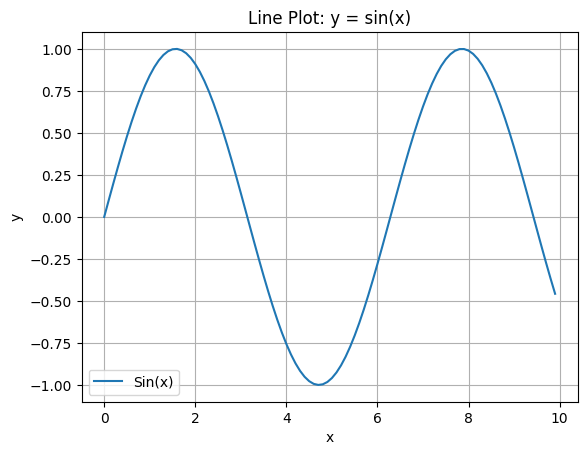

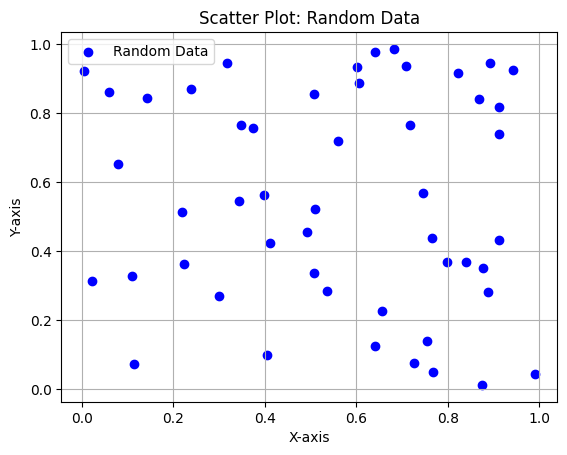

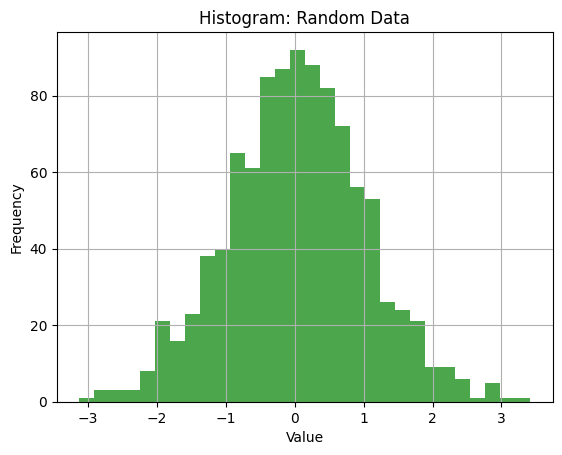

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Generate random data
x = np.arange(0, 10, 0.1)
y = np.sin(x)

# Plotting the line plot
plt.plot(x, y, label='Sin(x)')
plt.title('Line Plot: y = sin(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()

# Generate random data
x = np.random.rand(50)
y = np.random.rand(50)

# Plotting the scatter plot
plt.scatter(x, y, color='blue', label='Random Data')
plt.title('Scatter Plot: Random Data')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid()
plt.show()

# Generate random data
data = np.random.randn(1000)

# Plotting the histogram
plt.hist(data, bins=30, color='green', alpha=0.7)
plt.title('Histogram: Random Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid()
plt.show()

### Let's analyse the code

#### Creating Data for a Line Plot
```python
x = np.arange(0, 10, 0.1)
y = np.sin(x)
```

    A continuous sequence of x-values is generated.

    The sine of each x-value is computed to form a smooth periodic dataset.

---

#### Drawing the Line Plot

```python
plt.plot(x, y, label='Sin(x)')
plt.title('Line Plot: y = sin(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()
```

    A line graph is drawn to represent the mathematical relationship y = sin(x).

    The grid and labels improve readability and interpretation.

---

#### Creating Data for a Scatter Plot

```python
x = np.random.rand(50)
y = np.random.rand(50)
```

    Two independent sets of random values are generated,
    representing uncorrelated observations.

---

#### Drawing the Scatter Plot

```python
plt.scatter(x, y, color='blue', label='Random Data')
plt.title('Scatter Plot: Random Data')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid()
plt.show()
```

    Individual data points are displayed to visualise their distribution.

---

#### Creating Data for a Histogram

```python
data = np.random.randn(1000)
```

    A large dataset is generated following a normal distribution.

---

#### Drawing the Histogram

```python
plt.hist(data, bins=30, color='green', alpha=0.7)
plt.title('Histogram: Random Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid()
plt.show()
```

    The histogram groups the data into bins and displays their frequency.

    The resulting plot illustrates the statistical distribution of the dataset.


## Ex8 Generating and Plotting Random Data (Scatter Plot):

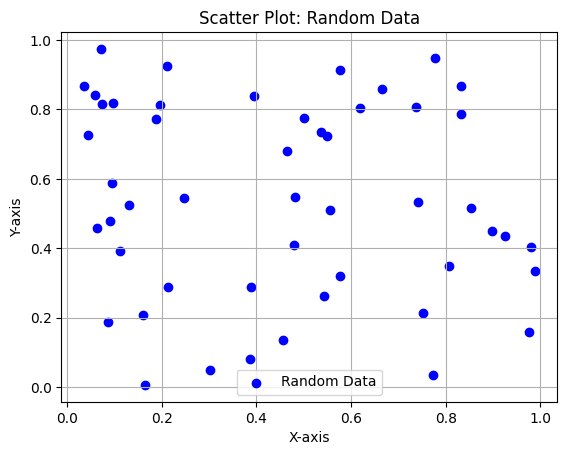

In [8]:
# Generate random data
x = np.random.rand(50)
y = np.random.rand(50)

# Plotting the scatter plot
plt.scatter(x, y, color='blue', label='Random Data')
plt.title('Scatter Plot: Random Data')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid()
plt.show()

### Let's analyse the code

#### Creating Data for the Scatter Plot
```python
x = np.random.rand(50)
y = np.random.rand(50)
```

    Two sets of 50 random values are generated.
    Each pair (x[i], y[i]) represents one independent data point.

---

#### Drawing the Scatter Plot

```python
plt.scatter(x, y, color='blue', label='Random Data')
plt.title('Scatter Plot: Random Data')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid()
plt.show()
```

    The scatter plot displays individual data points in a 2D plane.

    This visualisation is used to observe distribution patterns,
    clustering behaviour, and potential correlations between variables.


## Ex9 Generating and Plotting Random Data (Histogram)

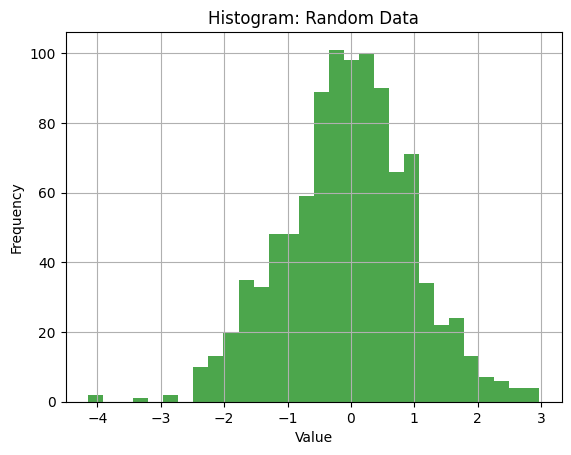

In [9]:
# Generate random data
data = np.random.randn(1000)

# Plotting the histogram
plt.hist(data, bins=30, color='green', alpha=0.7)
plt.title('Histogram: Random Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid()
plt.show()

### Let's analyse the code

#### Creating Data for the Histogram
```python
data = np.random.randn(1000)
```

    A dataset of 1000 values is generated following a normal distribution.

    The values are centred around zero with natural variation,
    simulating real-world continuous measurements.

---

#### Drawing the Histogram

```python
plt.hist(data, bins=30, color='green', alpha=0.7)
plt.title('Histogram: Random Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid()
plt.show()
```

    The histogram groups the data into 30 bins and displays their frequency.

    This visualisation reveals the overall shape of the distribution,
    making it possible to identify skewness, spread, and central tendency.


## Ex10 Generating and Plotting Random Data in the same figure

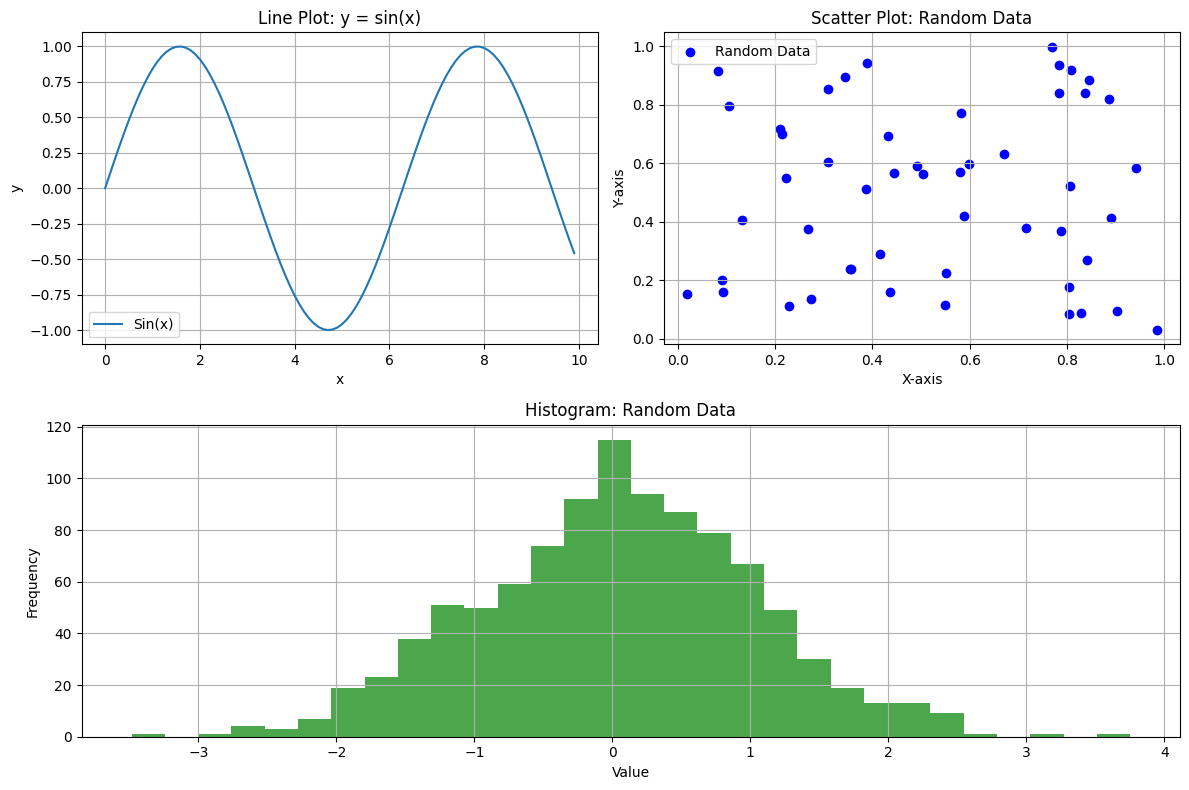

In [10]:
# Data for line plot
x_line = np.arange(0, 10, 0.1)
y_line = np.sin(x_line)

# Data for scatter plot
x_scatter = np.random.rand(50)
y_scatter = np.random.rand(50)

data_histogram = np.random.randn(1000)

# Create subplots
plt.figure(figsize=(12, 8))

# Line Plot
plt.subplot(2, 2, 1)
plt.plot(x_line, y_line, label='Sin(x)')
plt.title('Line Plot: y = sin(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()

# Scatter Plot
plt.subplot(2, 2, 2)
plt.scatter(x_scatter, y_scatter, color='blue', label='Random Data')
plt.title('Scatter Plot: Random Data')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid()

# Histogram
plt.subplot(2, 2, (3,4))
plt.hist(data_histogram, bins=30, color='green', alpha=0.7)
plt.title('Histogram: Random Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid()

# Adjust layout for better spacing
plt.tight_layout()

# Save the figure as 'result.png'&nbsp;
plt.savefig('result.png', dpi=300, bbox_inches='tight')

# Show the combined plot
plt.show()

### Let's analyse the code

#### Preparing the Datasets

```python
x_line = np.arange(0, 10, 0.1)
y_line = np.sin(x_line)

x_scatter = np.random.rand(50)
y_scatter = np.random.rand(50)

data_histogram = np.random.randn(1000)
```

    Three independent datasets are created:
    a continuous signal for the line plot,
    random pairs for the scatter plot,
    and a normally distributed dataset for the histogram.

---

#### Creating the Figure Layout

```python
plt.figure(figsize=(12, 8))
```

    A large figure canvas is created to display multiple plots clearly.

---

#### Constructing the Line Plot

```python
plt.subplot(2, 2, 1)
plt.plot(x_line, y_line, label='Sin(x)')
```

    The first subplot position is selected.

    A sine wave is drawn to illustrate a continuous mathematical relationship.

---

#### Constructing the Scatter Plot

```python
plt.subplot(2, 2, 2)
plt.scatter(x_scatter, y_scatter, color='blue', label='Random Data')
```

    The second subplot position is selected.

    Random data points are displayed to show their spatial distribution.

---

#### Constructing the Histogram

```python
plt.subplot(2, 2, (3,4))
plt.hist(data_histogram, bins=30, color='green', alpha=0.7)
```

    The bottom two subplot positions are merged.

    The histogram visualises the statistical distribution of the dataset.

---

#### Adjusting and Saving the Layout

```python
plt.tight_layout()
plt.savefig('result.png', dpi=300, bbox_inches='tight')
```

    The layout is optimised for spacing and visual clarity.

    The entire figure is saved as a high-resolution image.

---

#### Displaying the Result

```python
plt.show()
```

    The combined visualisation containing all three plot types is rendered.

    This structure demonstrates how multiple related datasets
    can be compared within a single organised figure.


## Ex11 3D Visualisation of Discrete and Continuous Data

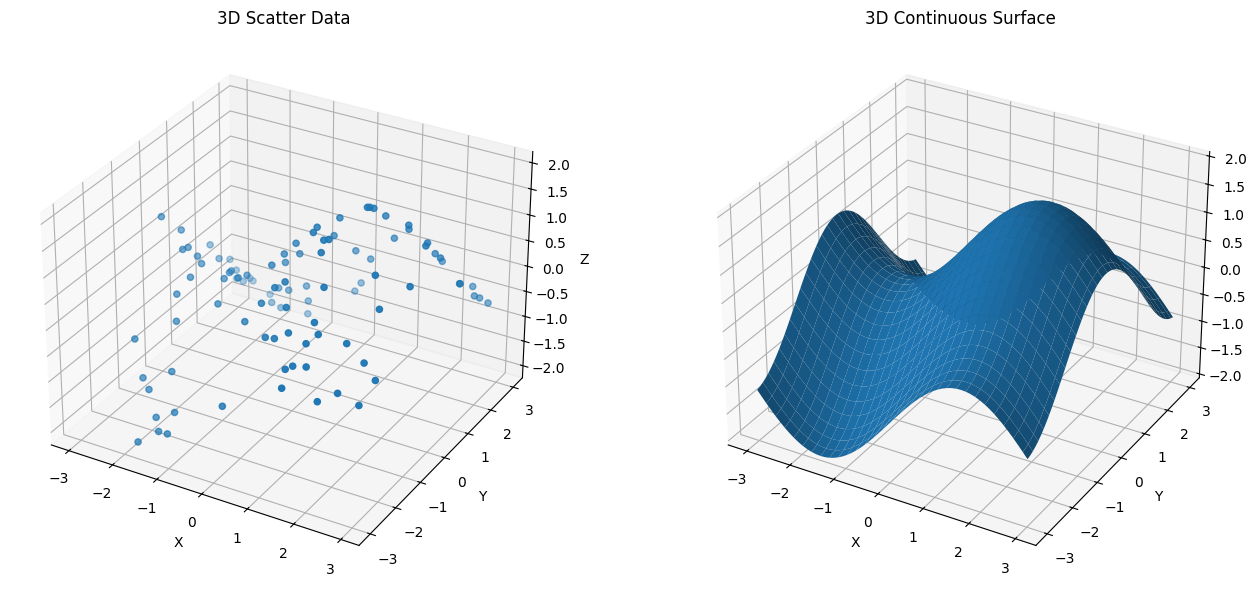

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --------- Generate Data ---------

# Discrete scatter data
x_scatter = np.random.uniform(-3, 3, 100)
y_scatter = np.random.uniform(-3, 3, 100)
z_scatter = np.sin(x_scatter) + np.cos(y_scatter)

# Continuous surface data
x = np.linspace(-3, 3, 60)
y = np.linspace(-3, 3, 60)
X, Y = np.meshgrid(x, y)
Z = np.sin(X) + np.cos(Y)

# --------- Plot Side-by-Side 3D Visualisations ---------

fig = plt.figure(figsize=(14, 6))

# 3D Scatter Plot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(x_scatter, y_scatter, z_scatter)
ax1.set_title("3D Scatter Data")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")

# 3D Continuous Surface Plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X, Y, Z)
ax2.set_title("3D Continuous Surface")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")

plt.tight_layout()
plt.show()


### Generating Discrete Scatter Data

```python
x_scatter = np.random.uniform(-3, 3, 100)
y_scatter = np.random.uniform(-3, 3, 100)
z_scatter = np.sin(x_scatter) + np.cos(y_scatter)
```

    Three arrays of random values are created.
    Each point represents an individual sampled measurement in 3D space.
    The Z-values are computed from a mathematical relationship
    combining sine and cosine functions.

---

#### Generating Continuous Surface Data

```python
x = np.linspace(-3, 3, 60)
y = np.linspace(-3, 3, 60)
X, Y = np.meshgrid(x, y)
Z = np.sin(X) + np.cos(Y)
```

    A continuous grid is created over the X–Y plane.
    For every point in this grid, the Z-value is computed using
    the same mathematical model as the scatter data.

---

#### Creating the Figure Layout

```python
fig = plt.figure(figsize=(14, 6))
```

    A large figure is created to display both plots side-by-side.

---

#### Drawing the 3D Scatter Plot

```python
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(x_scatter, y_scatter, z_scatter)
```

    The first subplot displays discrete sample data in three dimensions.
    Each point is plotted individually.

---

#### Drawing the 3D Surface Plot

```python
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X, Y, Z)
```

    The second subplot displays a continuous surface generated
    from the same underlying mathematical relationship.

---

#### Labelling and Displaying the Visualisation

```python
ax1.set_title("3D Scatter Data")
ax2.set_title("3D Continuous Surface")
plt.tight_layout()
plt.show()
```

    Titles and labels improve interpretability.
    The final figure demonstrates the relationship between
    discrete sampled data and its continuous model representation.
```

### Introduction to Clustering Algorithms

    Clustering is an unsupervised learning technique used to group data points
    based on their similarity. Unlike supervised learning, clustering does not
    rely on labelled data. Instead, it discovers underlying patterns and
    structures within the dataset.

    Clustering is commonly used when:
    - The natural grouping of data is unknown.
    - Labels are unavailable or expensive to obtain.
    - The goal is exploratory data analysis and pattern discovery.
    - One wishes to understand the internal structure of complex datasets.

---

### When to Use Clustering Algorithms

    Clustering algorithms are appropriate when:
    - You want to explore the structure of your data before building models.
    - You suspect the presence of meaningful groups but do not know them in advance.
    - You need to detect anomalies or outliers in the dataset.
    - You wish to compress or summarise data by representative groups.
    - You want to understand customer segments, biological classes,
      behavioural patterns, or sensor regimes.

    In scientific contexts, clustering is especially valuable for:
    - Species classification and phenotype discovery.
    - Genomic and medical data analysis.
    - Environmental monitoring and ecological modelling.
    - Image segmentation and pattern recognition.

---

### Overview of the Four Clustering Algorithms

#### 1. K-Means Clustering

    K-Means partitions data into a predefined number of clusters (K) by minimising
    the distance between points and their assigned cluster centroids.

    Best used when:
    - The number of clusters is known or can be estimated.
    - Clusters are roughly spherical and of similar size.
    - The dataset is large and efficiency is important.

---

#### 2. Hierarchical Agglomerative Clustering

    Hierarchical clustering builds a tree-like structure of clusters by repeatedly
    merging the closest groups of data points.

    Best used when:
    - The number of clusters is unknown.
    - Interpretability and understanding cluster relationships are important.
    - You want to explore clustering at multiple resolutions.

---

#### 3. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

    DBSCAN identifies clusters as dense regions of data separated by areas of low
    density, automatically detecting outliers as noise.

    Best used when:
    - The number of clusters is unknown.
    - Clusters have irregular shapes.
    - Noise and outlier detection are important.

---

#### 4. Gaussian Mixture Model (GMM)

    GMM models data as a mixture of multiple Gaussian distributions and assigns
    probabilities of membership for each data point.

    Best used when:
    - Clusters overlap in feature space.
    - Soft clustering is desired.
    - A probabilistic interpretation of clusters is valuable.

---

### Summary

    The choice of clustering algorithm depends on the data structure, the problem
    context, and the desired interpretability. Using multiple clustering methods
    and comparing their outcomes is often the most effective approach to uncover
    meaningful insights.
```


## Generation of Synthetic data

In [12]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)
cluster_1 = np.random.randn(80, 2) + np.array([0, 0])
cluster_2 = np.random.randn(80, 2) + np.array([4, 4])
cluster_3 = np.random.randn(80, 2) + np.array([-2, 5])
X = np.vstack([cluster_1, cluster_2, cluster_3])

### Let's analyse the code

#### Generating the Synthetic Dataset

```python
np.random.seed(1)
cluster_1 = np.random.randn(80, 2) + np.array([0, 0])
cluster_2 = np.random.randn(80, 2) + np.array([4, 4])
cluster_3 = np.random.randn(80, 2) + np.array([-2, 5])
X = np.vstack([cluster_1, cluster_2, cluster_3])
```

    A fixed random seed ensures reproducibility of the experiment.

    Three independent clusters are generated in a two-dimensional feature space.

    Each cluster consists of 80 points drawn from a normal distribution,
    then shifted to different locations in the plane.

    The resulting cluster centres are approximately located at:
    (0, 0), (4, 4), and (-2, 5).

    np.vstack combines the three clusters into one dataset X,
    producing a total of 240 samples.

    This dataset simulates a common real-world clustering scenario
    where several natural groups exist within noisy observations.


## Ex12 K-Means Clustering

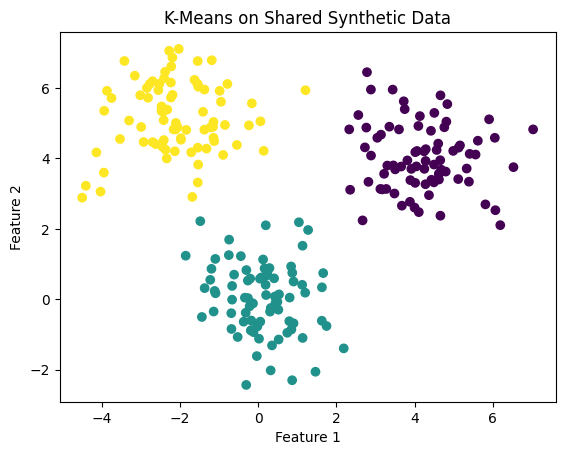

In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
labels_kmeans = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels_kmeans)
plt.title("K-Means on Shared Synthetic Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Let's analyse the code

#### Applying K-Means Clustering

```python
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
labels_kmeans = kmeans.fit_predict(X)
```

    The algorithm is configured to partition the dataset into three clusters.

    fit_predict() performs two actions:
    - Learns the cluster centroids from the data.
    - Assigns each data point to its nearest centroid.

    The result is an array of cluster labels where each value indicates
    the cluster membership of the corresponding data point.

---

#### Visualising the K-Means Clustering Result

```python
plt.scatter(X[:, 0], X[:, 1], c=labels_kmeans)
plt.title("K-Means on Shared Synthetic Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()
```

    Each point is plotted in the 2D feature space.

    The colour of each point represents the cluster assigned by K-Means.

    This visualisation allows direct observation of how well the algorithm
    has separated the underlying synthetic clusters.

    For this dataset, K-Means is expected to produce compact,
    well-separated groups due to the structure of the generated data.


## Ex13 Hierarchical Agglomerative Clustering

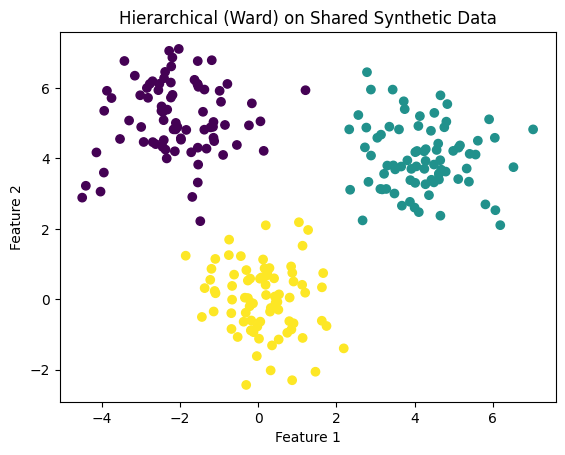

In [14]:
from sklearn.cluster import AgglomerativeClustering

hier = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels_hier = hier.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels_hier)
plt.title("Hierarchical (Ward) on Shared Synthetic Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Let's analyse the code

#### Applying Hierarchical Agglomerative Clustering

```python
hier = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels_hier = hier.fit_predict(X)
```

    The algorithm is configured to produce three clusters.

    Agglomerative clustering begins with each data point as its own cluster
    and progressively merges clusters based on similarity.

    The "ward" linkage strategy merges clusters in a way that minimises
    the increase in total within-cluster variance.

    fit_predict() constructs the hierarchy and assigns each data point
    to one of the final three clusters.

---

#### Visualising the Hierarchical Clustering Result

```python
plt.scatter(X[:, 0], X[:, 1], c=labels_hier)
plt.title("Hierarchical (Ward) on Shared Synthetic Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()
```

    Each point is plotted in the 2D feature space.

    The colour of each point represents the cluster assigned by the
    hierarchical clustering process.

    This visualisation reveals how the algorithm groups the synthetic
    data based on spatial similarity.

    On this dataset, the result is expected to be similar to K-Means,
    as both aim to produce compact and well-separated clusters.


## Ex14 DBSCAN

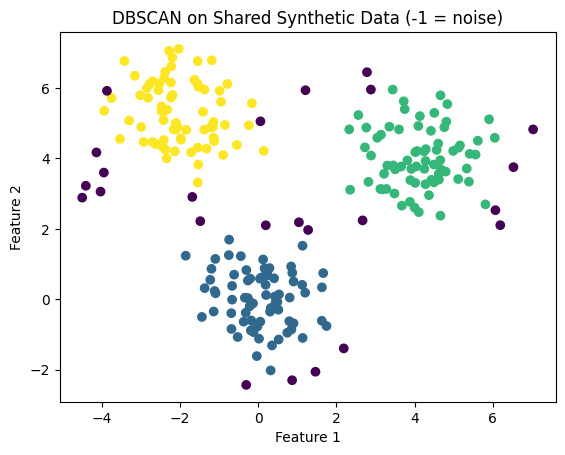

Clusters found (excluding noise): 3
Noise points: 24


In [15]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.8, min_samples=6)
labels_db = db.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels_db)
plt.title("DBSCAN on Shared Synthetic Data (-1 = noise)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print("Clusters found (excluding noise):", len(set(labels_db)) - (1 if -1 in labels_db else 0))
print("Noise points:", np.sum(labels_db == -1))


### Let's analyse the code

#### Applying DBSCAN Clustering

```python
db = DBSCAN(eps=0.8, min_samples=6)
labels_db = db.fit_predict(X)
```

    DBSCAN groups data points based on local point density.

    eps defines the neighbourhood radius used to determine
    whether points are considered close to each other.

    min_samples defines the minimum number of neighbouring points
    required to form a dense region (a cluster).

    fit_predict() discovers dense regions in the dataset and assigns:
    - a cluster label to core and border points,
    - the label -1 to noise points that do not belong to any cluster.

---

#### Visualising the DBSCAN Result

```python
plt.scatter(X[:, 0], X[:, 1], c=labels_db)
plt.title("DBSCAN on Shared Synthetic Data (-1 = noise)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()
```

    Each point is plotted in the 2D feature space.

    The colour of each point corresponds to its assigned label.

    Points coloured with -1 represent noise, highlighting samples
    that do not fit well into any dense region.

---

#### Interpreting Cluster and Noise Counts

```python
print("Clusters found (excluding noise):", len(set(labels_db)) - (1 if -1 in labels_db else 0))
print("Noise points:", np.sum(labels_db == -1))
```

    The number of discovered clusters is computed while excluding noise.

    The number of noise points indicates how many samples were
    considered outliers by the algorithm.

    DBSCAN’s output is highly sensitive to the chosen eps and
    min_samples values, making parameter selection a critical
    part of effective density-based clustering.


## Ex15 Gaussian Mixture Model

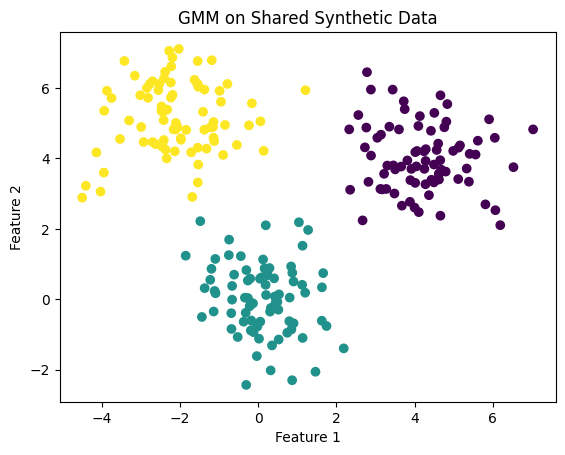

In [16]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=0)
labels_gmm = gmm.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels_gmm)
plt.title("GMM on Shared Synthetic Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Let's analyse the code

#### Applying Gaussian Mixture Model Clustering

```python
gmm = GaussianMixture(n_components=3, random_state=0)
labels_gmm = gmm.fit_predict(X)
```

    The Gaussian Mixture Model assumes that the dataset is generated
    from a mixture of three Gaussian probability distributions.

    n_components specifies the number of Gaussian components (clusters).

    fit_predict() estimates the parameters of the Gaussian distributions
    and assigns each data point to the component with the highest
    likelihood.

    Unlike K-Means, GMM produces soft probabilistic assignments internally,
    even though fit_predict() returns the most likely cluster for each point.

---

#### Visualising the GMM Clustering Result

```python
plt.scatter(X[:, 0], X[:, 1], c=labels_gmm)
plt.title("GMM on Shared Synthetic Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()
```

    Each point is plotted in the 2D feature space.

    The colour of each point represents the cluster assignment produced
    by the Gaussian Mixture Model.

    GMM is capable of modelling elliptical clusters and overlapping
    group structures, making it especially useful when natural
    clusters are not well separated.


# Apply your knowledge - Visualisation & Clustering with the Iris Dataset

## Dataset Description

You will work with the file:

    iris.json

This dataset contains measurements of 150 iris flowers, where each record has:

    - sepalLength  
    - sepalWidth  
    - petalLength  
    - petalWidth  
    - species   ("setosa", "versicolor", "virginica")

Example record:

```json
{
  "sepalLength": 5.1,
  "sepalWidth": 3.5,
  "petalLength": 1.4,
  "petalWidth": 0.2,
  "species": "setosa"
}
```

---

## Objective

By the end of this lab, you will:

- Load and explore the Iris dataset.
- Visualise the data in 2D and 3D.
- Apply four clustering algorithms:
  - K-Means
  - Hierarchical (Agglomerative)
  - DBSCAN
  - Gaussian Mixture Model (GMM)
- Compare how each algorithm groups the same dataset.
- Interpret the results scientifically.

Your final output must be a Jupyter Notebook named:

    practical_lab.ipynb

structured similarly to the provided reference notebook.

---

## Part 1 — Load & Explore the Data

### Task 1: Load the Dataset

Load `iris.json` into Python and inspect:

- Number of samples
- Feature names
- Unique species labels

Briefly describe what each feature represents biologically.

---

## Part 2 — Visualisation

### Task 2: 2D Visualisation

Create a 2D scatter plot of:

    Sepal Length (x-axis) vs Sepal Width (y-axis)

Colour the points by species and include:

- Axis labels
- Title
- Legend

Explain what patterns you observe.

---

### Task 3: 3D Visualisation

Create a 3D scatter plot using:

    X = sepalLength  
    Y = sepalWidth  
    Z = petalLength  

Use colour or marker type to represent species.

Explain why adding the third dimension improves separability.

---

## Part 3 — Clustering Analysis

Apply **all four clustering algorithms** to the same feature set:

    [sepalLength, sepalWidth, petalLength, petalWidth]

Before clustering, normalise the features.

For **each algorithm**, you must include:

1) The Python implementation  
2) A 2D clustered plot  
3) A 3D clustered plot  
4) A written interpretation  

### Algorithms to apply:

- K-Means (k = 3)
- Hierarchical Agglomerative (Ward linkage, 3 clusters)
- DBSCAN (tune eps and min_samples)
- Gaussian Mixture Model (3 components)

---

## Part 4 — Interpretation & Comparison

Write a comparison section answering:

- Which algorithm best separated the three species?
- Which struggled the most and why?
- How did 2D and 3D views change your interpretation?
- Which algorithm would you choose for:
    - Well-separated data
    - Noisy data
    - Overlapping clusters

---

## Learning Outcome

This lab demonstrates how **visualisation and clustering together**
reveal the underlying structure of real biological data.